# Milestone 1 — what the numbers actually are

Every greenness number in this project is the same five steps. This notebook runs them one at a
time so none of it has to be taken on trust.

1. Get the **shape** of a place from OpenStreetMap
2. Ask Earth Engine which **satellite photos** cover that shape in a given Feb–Mar
3. Stack the photos, take the **middle value** per pixel (this is what removes clouds)
4. Apply the greenness **formula** to two colour bands
5. **Average** across every pixel inside the shape → one number

There is no model and nothing learned. Step 4 is one division. Which is also the weakness: the
arithmetic cannot tell a tree from a lawn from a mat of water hyacinth.

Run top to bottom. Needs `EE_PROJECT` set.

In [1]:
import json, math, os
from pathlib import Path

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
SCALE_M = 10                 # Sentinel-2 pixel size in metres
DRY_SEASON = ("02-01", "03-31")

ee.Initialize(project=os.environ["EE_PROJECT"])
print("Earth Engine ready:", os.environ["EE_PROJECT"])

Earth Engine ready: project-id-0186438029819335325


---
## Step 1 — the shape

Not a coordinate. A traced outline, pinned by OpenStreetMap id.

This distinction is load-bearing. A hand-typed point once put the Kaikondrahalli sample ~450 m off
target, on land beside the lake, and it returned perfectly plausible numbers — see gotcha 7 in
`PROJECT.md`. Shapes pinned by id cannot drift that way, and `fetch_sites.py` additionally asserts
each one falls inside an expected bounding box, so a rename upstream fails loudly.

,osm,display_name
site,,
lalbagh,W15802464,"Lalbagh Botanical Gardens, Ashoka Pillar, Beng..."
kaikondrahalli_lake,R6820030,"Kaikondrahalli Lake, Kasavanahalli, Bengaluru ..."
varthur_lake,R19306126,"Varthur Lake, Varthur, Bengaluru East City Cor..."
varthur_area,R19883430,"Varthur, Bengaluru East City Corporation, Beng..."


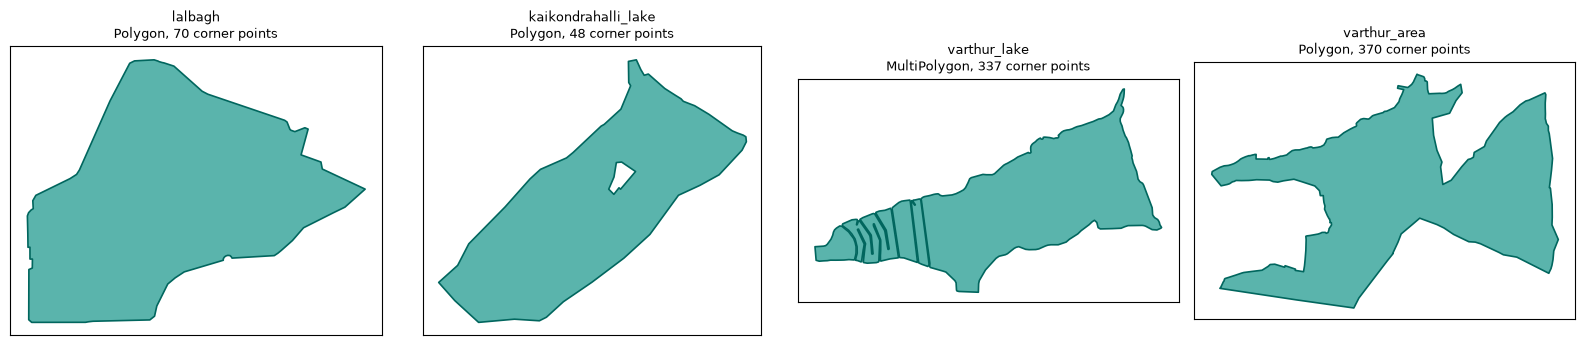

In [2]:
sites = gpd.read_file("data/osm_sites.geojson").set_index("site")
display(sites[["osm", "display_name"]])

fig, axes = plt.subplots(1, len(sites), figsize=(4 * len(sites), 3.4))
for ax, (name, row) in zip(axes, sites.iterrows()):
    gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor="#5ab4ac", edgecolor="#01665e", linewidth=1.2)
    n_pts = len(row.geometry.exterior.coords) if row.geometry.geom_type == "Polygon" else sum(
        len(g.exterior.coords) for g in row.geometry.geoms)
    ax.set_title(f"{name}\n{row.geometry.geom_type}, {n_pts} corner points", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

### The two regions that are *derived*, not fetched

`varthur_built` and the Kaikondrahalli rims do not exist in OpenStreetMap. They are built by
subtraction, and getting this wrong is the easiest way to produce a confident wrong answer:

- **`varthur_built`** = the Varthur area **minus Varthur lake**. The lake is removed because open
  water is meaningless in a greenness average — and, as it turns out, because the lake was covered
  in hyacinth reading as *dense vegetation* at 0.82.
- **the rims** = a ring around Kaikondrahalli lake, at three widths, each with the lake itself
  punched out.

In [3]:
g = {name: ee.Geometry(row.geometry.__geo_interface__) for name, row in sites.iterrows()}

RIMS = (50, 100, 200)
regions = {
    "lalbagh": g["lalbagh"],
    "kaikondrahalli_lake": g["kaikondrahalli_lake"],
    **{f"kaikondrahalli_rim_{m}": g["kaikondrahalli_lake"].buffer(m)
                                   .difference(g["kaikondrahalli_lake"], maxError=1) for m in RIMS},
    "varthur_built": g["varthur_area"].difference(g["varthur_lake"], maxError=1),
    # the 150 m rim of Varthur lake. NOTE this sits *inside* varthur_built - it is a
    # sub-region of that number, not an independent site. Expect the two to correlate.
    "varthur_lake_ring_150": (g["varthur_lake"].buffer(150)
                              .difference(g["varthur_lake"], maxError=1)
                              .intersection(g["varthur_area"], maxError=1)),
}

areas = ee.List([regions[k].area(maxError=1) for k in regions]).getInfo()
pd.DataFrame({"region": list(regions), "area_km2": [round(a / 1e6, 3) for a in areas]}).set_index("region")

,area_km2
region,
lalbagh,0.912
kaikondrahalli_lake,0.166
kaikondrahalli_rim_50,0.105
kaikondrahalli_rim_100,0.223
kaikondrahalli_rim_200,0.505
varthur_built,7.631
varthur_lake_ring_150,0.611


---
## Step 2 — which photos exist

Sentinel-2 revisits every ~5 days, but a given Feb–Mar window only has as many usable images as the
archive actually holds. The count per year is not constant, and the early years are thin for a
reason worth knowing: it is the *atmospherically corrected* product (L2A) that was backfilled
patchily, not the raw imagery. Feb–Mar 2016 has a single usable scene, and it sits on the wrong
tile.

`varthur_built` shows roughly double everywhere because that polygon straddles two satellite tiles.
That is scenes-*intersecting*, not scenes-per-pixel — coverage is equivalent, not better.

,lalbagh,kaikondrahalli_lake,kaikondrahalli_rim_50,kaikondrahalli_rim_100,kaikondrahalli_rim_200,varthur_built,varthur_lake_ring_150
year,,,,,,,
2016,0,0,0,0,0,1,0
2017,2,2,2,2,2,4,2
2018,4,4,4,4,4,7,4
2019,12,12,12,12,12,24,12
2020,12,12,12,12,12,24,12
2021,12,12,12,12,12,24,12
2022,12,12,12,12,12,24,12
2023,12,12,12,12,12,24,12
2024,12,12,12,12,12,24,12


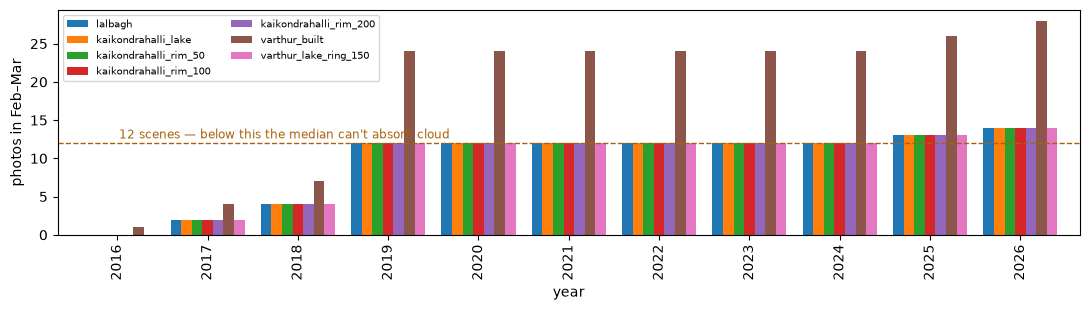

In [4]:
YEARS = list(range(2016, 2027))

def dry_season(year, region):
    return (ee.ImageCollection(COLLECTION)
            .filterBounds(region)
            .filterDate(f"{year}-{DRY_SEASON[0]}", f"{year}-{DRY_SEASON[1]}"))

names = list(regions)
counts = ee.List([ee.List([dry_season(y, regions[n]).size() for n in names]) for y in YEARS]).getInfo()
scene_counts = pd.DataFrame(counts, index=YEARS, columns=names)
scene_counts.index.name = "year"

ax = scene_counts.plot(kind="bar", figsize=(11, 3.2), width=0.82)
ax.axhline(12, color="#a8620d", linestyle="--", linewidth=1)
ax.text(0.02, 12.6, "12 scenes — below this the median can't absorb cloud",
        color="#a8620d", fontsize=8.5)
ax.set_ylabel("photos in Feb–Mar"); ax.legend(fontsize=7.5, ncol=2)
plt.tight_layout()
scene_counts

---
## Step 3 — the median, and why it is the whole trick

Take one pixel. Look at its **red** brightness in each of this year's photos, sorted.

The large values at the top of that sorted list are clouds. Taking the **middle** value discards
them without ever having to detect them. That is why this pipeline has no cloud-masking code —
and equally why 2 or 4 photos is not enough: with a handful of values there is no middle to hide
behind, and one hazy scene moves the answer.

red, sorted: [408, 486, 524, 560, 637, 641, 683, 694, 871, 880, 2249, 4709, 4990, 7545]
near-IR,    : [2147, 2185, 2244, 2257, 2263, 2284, 2309, 2358, 2380, 2404, 2879, 4348, 4360, 7456]

median red     688.5
median near-IR 2333.5


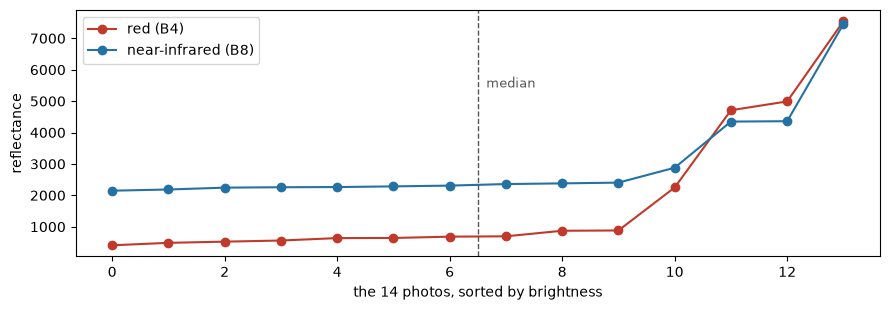

In [5]:
YEAR = 2026
probe = ee.Geometry.Point([77.5868882, 12.9488492])      # centre of Lalbagh

region_rows = dry_season(YEAR, regions["lalbagh"]).select(["B4", "B8"]).getRegion(probe, SCALE_M).getInfo()
hdr, rows = region_rows[0], region_rows[1:]
red = sorted(r[hdr.index("B4")] for r in rows if r[hdr.index("B4")] is not None)
nir = sorted(r[hdr.index("B8")] for r in rows if r[hdr.index("B8")] is not None)

def median(v):
    n = len(v)
    return v[n // 2] if n % 2 else (v[n // 2 - 1] + v[n // 2]) / 2

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(red, "o-", label="red (B4)", color="#c0392b")
ax.plot(nir, "o-", label="near-infrared (B8)", color="#2471a3")
ax.axvline((len(red) - 1) / 2, color="#555", linestyle="--", linewidth=1)
ax.text((len(red) - 1) / 2 + 0.15, max(red) * 0.72, "median", fontsize=9, color="#555")
ax.set_xlabel(f"the {len(red)} photos, sorted by brightness"); ax.set_ylabel("reflectance")
ax.legend(); plt.tight_layout()

print("red, sorted:", red)
print("near-IR,    :", nir)
print(f"\nmedian red     {median(red)}")
print(f"median near-IR {median(nir)}")

---
## Step 4 — the formula

Living vegetation reflects near-infrared strongly and absorbs red. So the gap between those two
bands, scaled by their sum, tracks how much photosynthesis is happening:

$$\text{greenness} = \frac{\text{near infrared} - \text{red}}{\text{near infrared} + \text{red}}$$

Runs −1 to +1. Bare ground and rooftops sit near 0–0.2, thick vegetation near 0.5+, open water goes
negative. It is conventionally called NDVI.

The cell below does the arithmetic by hand and asks Earth Engine for the same pixel, to show they
are the same operation rather than a lookup of some stored score.

In [6]:
r_med, n_med = median(red), median(nir)
by_hand = (n_med - r_med) / (n_med + r_med)

composite = dry_season(YEAR, regions["lalbagh"]).median()
greenness = composite.normalizedDifference(["B8", "B4"])
from_ee = greenness.reduceRegion(ee.Reducer.first(), probe, SCALE_M).getInfo()["nd"]

print(f"  ({n_med} - {r_med}) / ({n_med} + {r_med})")
print(f"= {n_med - r_med} / {n_med + r_med}")
print(f"= {by_hand:.6f}      <- by hand")
print(f"  {from_ee:.6f}      <- Earth Engine")
assert abs(by_hand - from_ee) < 1e-9, "these should be identical"
print("\nidentical.")

  (2333.5 - 688.5) / (2333.5 + 688.5)
= 1645.0 / 3022.0
= 0.544341      <- by hand
  0.544341      <- Earth Engine

identical.


---
## Step 5 — average over every pixel in the shape

One number per place per year. Nothing more sophisticated than a mean.

Note what a mean throws away: a shape that is half car park and half dense canopy averages to the
same value as one that is uniformly scrubby. Milestone 2 moves to per-pixel hexes precisely so the
map shows *where*, rather than collapsing everything to one figure per place.

In [7]:
mean_val = greenness.reduceRegion(ee.Reducer.mean(),  regions["lalbagh"], SCALE_M).getInfo()["nd"]
n_pix    = greenness.reduceRegion(ee.Reducer.count(), regions["lalbagh"], SCALE_M).getInfo()["nd"]
print(f"pixels inside the Lalbagh outline : {int(n_pix):,}")
print(f"their average greenness           : {mean_val:.6f}")

pixels inside the Lalbagh outline : 9,370
their average greenness           : 0.475991


---
## The whole measurement

Same five steps, every place, every year, in two server calls. Earth Engine builds the whole
calculation as a recipe, ships it once, and runs it on Google's machines — so this is *not* one
request per number.

Wetness (MNDWI, green vs shortwave-infrared) comes along free: same composite, different two bands.
It is the right probe for open water, where greenness is meaningless.

In [8]:
fc = ee.FeatureCollection([ee.Feature(regions[n], {"site": n}) for n in names])

def indices(collection):
    c = collection.median()
    return (c.normalizedDifference(["B8", "B4"]).rename("green")
             .addBands(c.normalizedDifference(["B3", "B11"]).rename("wet")))

usable = [y for y in YEARS if scene_counts.loc[y].max() > 0]
stats = ee.FeatureCollection([
    indices(dry_season(y, fc)).reduceRegions(fc, ee.Reducer.mean(), SCALE_M).map(lambda f, y=y: f.set("year", y))
    for y in usable
]).flatten().getInfo()["features"]

df = pd.DataFrame([f["properties"] for f in stats])
green = df.pivot(index="year", columns="site", values="green")[names]
wet   = df.pivot(index="year", columns="site", values="wet")[names]
green.round(3)

site,lalbagh,kaikondrahalli_lake,kaikondrahalli_rim_50,kaikondrahalli_rim_100,kaikondrahalli_rim_200,varthur_built,varthur_lake_ring_150
year,,,,,,,
2016,NaN,NaN,NaN,NaN,NaN,0.274,NaN
2017,0.452,0.290,0.317,0.274,0.249,0.339,0.501
2018,0.458,0.372,0.330,0.274,0.247,0.333,0.496
2019,0.458,0.353,0.281,0.228,0.196,0.265,0.435
2020,0.438,0.342,0.294,0.237,0.210,0.260,0.370
2021,0.494,0.226,0.353,0.297,0.265,0.310,0.378
2022,0.465,0.113,0.355,0.306,0.266,0.296,0.363
2023,0.475,0.162,0.373,0.315,0.270,0.297,0.356
2024,0.450,0.291,0.325,0.271,0.234,0.223,0.303


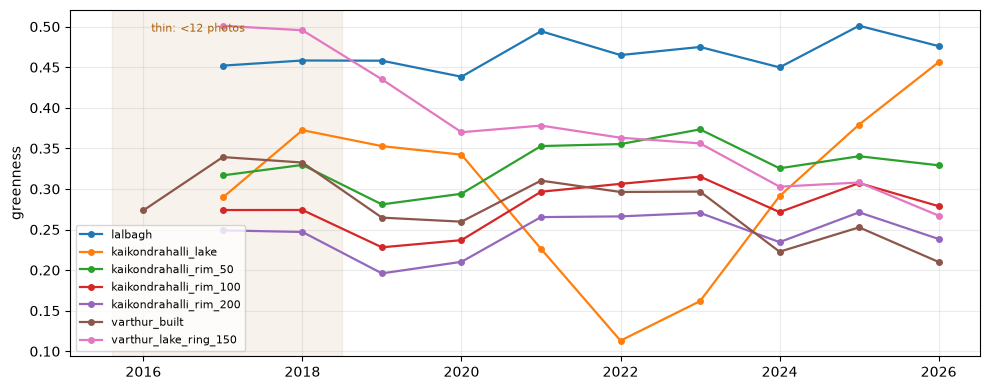

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for n in names:
    ax.plot(green.index, green[n], "o-", label=n, linewidth=1.6, markersize=4)
ax.axvspan(2015.6, 2018.5, color="#a8620d", alpha=0.08)
ax.text(2016.1, ax.get_ylim()[1] * 0.97, "thin: <12 photos", fontsize=8, color="#a8620d", va="top")
ax.set_ylabel("greenness"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

---
## Order of operations — does it matter?

Worth pinning down, because there are two ways to compare 2019 with 2026 and they are not obviously
the same thing.

**Way A — average, then subtract.** Average every pixel in the shape for 2019 → one number. Do the
same for 2026. Subtract the two numbers. *This is what every figure so far has used.*

**Way B — subtract, then average.** For each pixel individually, compute its 2026 greenness minus
its 2019 greenness. Then average those differences.

One clarification first, since it is easy to state the formula slightly wrong: greenness is not
`red − infrared`. It is **infrared minus red, divided by their sum** — a *normalised* difference, so
it stays between −1 and +1 and does not inflate simply because a scene is brighter overall. Near
infrared comes first; vegetation is bright there and dark in red.

In [10]:
built = regions["varthur_built"]

def greenness_of(year, region):
    composite = (ee.ImageCollection(COLLECTION).filterBounds(region)
                 .filterDate(f"{year}-{DRY_SEASON[0]}", f"{year}-{DRY_SEASON[1]}").median())
    return composite.normalizedDifference(["B8", "B4"])

g19, g26 = greenness_of(2019, built), greenness_of(2026, built)

mean19 = g19.reduceRegion(ee.Reducer.mean(), built, SCALE_M, maxPixels=1e10).getInfo()["nd"]
mean26 = g26.reduceRegion(ee.Reducer.mean(), built, SCALE_M, maxPixels=1e10).getInfo()["nd"]
way_a = mean26 - mean19                                             # average, then subtract

per_pixel_change = g26.subtract(g19)                                # subtract, then average
way_b = per_pixel_change.reduceRegion(ee.Reducer.mean(), built, SCALE_M, maxPixels=1e10).getInfo()["nd"]

print(f"Way A   {mean26:.6f} - {mean19:.6f} = {way_a:+.6f}")
print(f"Way B                            = {way_b:+.6f}")
print(f"gap                              = {abs(way_a - way_b):.2e}")

Way A   0.210050 - 0.264652 = -0.054602
Way B                            = -0.054602
gap                              = 5.67e-15


**Identical**, to floating-point precision. Not a coincidence — the average of a set of differences
is the difference of the averages. Subtraction and averaging commute.

That holds on one condition: **both years must cover the same pixels.** If a pixel has a value in
2026 but not in 2019, Way A quietly averages two different sets of ground while Way B simply drops
that pixel. The cell below shows how many pixels each year actually has a value for.

In [11]:
coverage = pd.Series(
    ee.List([greenness_of(y, built).reduceRegion(ee.Reducer.count(), built, SCALE_M, maxPixels=1e10).get("nd")
             for y in YEARS]).getInfo(),
    index=YEARS, name="pixels_with_a_value")
coverage.to_frame().assign(pct_of_area=lambda d: (d.pixels_with_a_value / d.pixels_with_a_value.max() * 100).round(1))

,pixels_with_a_value,pct_of_area
2016,2234,2.8
2017,78469,100.0
2018,78469,100.0
2019,78469,100.0
2020,78469,100.0
2021,78469,100.0
2022,78469,100.0
2023,78469,100.0
2024,78469,100.0
2025,78469,100.0


Every year from 2017 on covers all 78,469 pixels — so the two orders agree, and Way A is safe.

**2016 covers 2,234 pixels: 2.8% of the polygon.** Its greenness of 0.274 is not a measurement of
Varthur; it is a measurement of the one corner of Varthur that the single available scene happened
to touch. Comparing it to any other year compares different ground. This is the concrete reason
2016 is dropped rather than merely flagged as thin — the sample is not small, it is *somewhere
else*.

### Why milestone 2 needs Way B anyway

Way A collapses a place to one number per year, which can only ever answer *how much*. Way B's
intermediate — `per_pixel_change`, computed above and never reduced — is a full image of change,
one value per 10 m pixel. That image **is** the deliverable: the swipe layer, the hex aggregates and
the "biggest change" ranking are all built from it. Averaging is the last step, not the method.

In [12]:
vis = per_pixel_change.visualize(min=-0.3, max=0.3,
                                 palette=["#8c2d04", "#fdd49e", "#f7f7f7", "#a6dba0", "#1b7837"])
edges = (ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(g["varthur_area"])]), 1, 2).selfMask()
         .visualize(palette=["#222222"]))
url = vis.blend(edges).getThumbURL({"region": g["varthur_area"].bounds(), "dimensions": 700, "format": "png"})
print("per-pixel change 2019 -> 2026   brown = lost greenness, green = gained, white = no change")
display(Image(url=url))

per-pixel change 2019 -> 2026   brown = lost greenness, green = gained, white = no change


This is milestone 2 in miniature, over one neighbourhood instead of the whole city. The single
number −0.0546 is the average of everything in that frame — and the frame shows plainly that the
average hides both directions. That is the entire argument for going per-pixel.

---
## The contested step: subtracting a control

Whole years move together. In 2021 *everything* is greener; in 2024 *everything* dips. That is
dry-season moisture and rainfall timing, not land cover — so an absolute per-year value cannot be
read as change (gotcha 8).

The fix used so far is to subtract Lalbagh, a mature botanical garden assumed to move only with the
weather.

**The objection, which is correct:** subtraction removes anything *common to both places*. Weather
is common. A genuine city-wide greening would also be common. They are the same arithmetic, and no
control site can separate them. If Bangalore really did green for a decade, this method deletes the
finding and reports nothing.

The cell below quantifies the cost. Watch the Lalbagh row: the control is itself drifting, and its
drift is **larger than the rim signal being tested for**.

In [13]:
FIT_YEARS = list(range(2019, 2027))     # every year has >=12 photos

def trend(series):
    y = [series[t] for t in FIT_YEARS]
    n = len(y); xs = list(range(n))
    mx, my = sum(xs) / n, sum(y) / n
    sxx = sum((x - mx) ** 2 for x in xs)
    slope = sum((x - mx) * (v - my) for x, v in zip(xs, y)) / sxx
    icept = my - slope * mx
    resid = [v - (icept + slope * x) for x, v in zip(xs, y)]
    sd = math.sqrt(sum(r * r for r in resid) / (n - 2))
    se = sd / math.sqrt(sxx)
    return pd.Series({"slope_per_year": slope, "std_error": se, "t": slope / se,
                      "run_8yr": y[-1] - y[0]})

ctrl = green["lalbagh"]
out = {}
for n in names:
    if n == "kaikondrahalli_lake":
        continue
    out[f"{n}  (raw)"] = trend(green[n])
    if n != "lalbagh":
        out[f"{n}  - lalbagh"] = trend(green[n] - ctrl)

fits = pd.DataFrame(out).T
fits["reads as"] = [
    "REAL" if abs(t) > 2.45 else "indistinguishable from noise" for t in fits["t"]
]
fits.round(4)

,slope_per_year,std_error,t,run_8yr,reads as
lalbagh (raw),0.0038,0.0032,1.1690,0.0180,indistinguishable from noise
kaikondrahalli_rim_50 (raw),0.0060,0.0046,1.3039,0.0482,indistinguishable from noise
kaikondrahalli_rim_50 - lalbagh,0.0022,0.0041,0.5432,0.0302,indistinguishable from noise
kaikondrahalli_rim_100 (raw),0.0076,0.0045,1.6879,0.0507,indistinguishable from noise
kaikondrahalli_rim_100 - lalbagh,0.0039,0.0036,1.0716,0.0327,indistinguishable from noise
kaikondrahalli_rim_200 (raw),0.0061,0.0042,1.4640,0.0424,indistinguishable from noise
kaikondrahalli_rim_200 - lalbagh,0.0023,0.0032,0.7376,0.0244,indistinguishable from noise
varthur_built (raw),-0.0081,0.0050,-1.6218,-0.0546,indistinguishable from noise
varthur_built - lalbagh,-0.0119,0.0037,-3.1842,-0.0726,REAL
varthur_lake_ring_150 (raw),-0.0205,0.0027,-7.5005,-0.1679,REAL


`|t| > 2.45` is the 5% threshold on 8 points. Read it as: *is the slope big compared to how much
the points scatter around it?*

Two things fall out, and they pull in opposite directions:

- **Subtraction earns its keep on Varthur.** The loss goes from `t = 1.62` (unprovable) to
  `t = 3.18` (real). It removed genuine shared noise.
- **Subtraction costs more than it earns on the rims.** Lalbagh drifts `+0.0038`/yr on its own.
  The rim "gain" being hunted is `+0.0022`/yr. The thing discarded is bigger than the thing sought,
  so a real city-wide greening of that size is unrecoverable here.

This is not a bug to fix — it is the boundary of what one control can do. Measuring a place
*relative to the rest of the city* is a real and defensible result, and it is what `PROJECT.md`'s
scope decisions already committed to ("a map of *where* it changed rather than a city-wide
average"). The absolute question needs a control that is not itself vegetation — rainfall data,
say — and that is a different project.

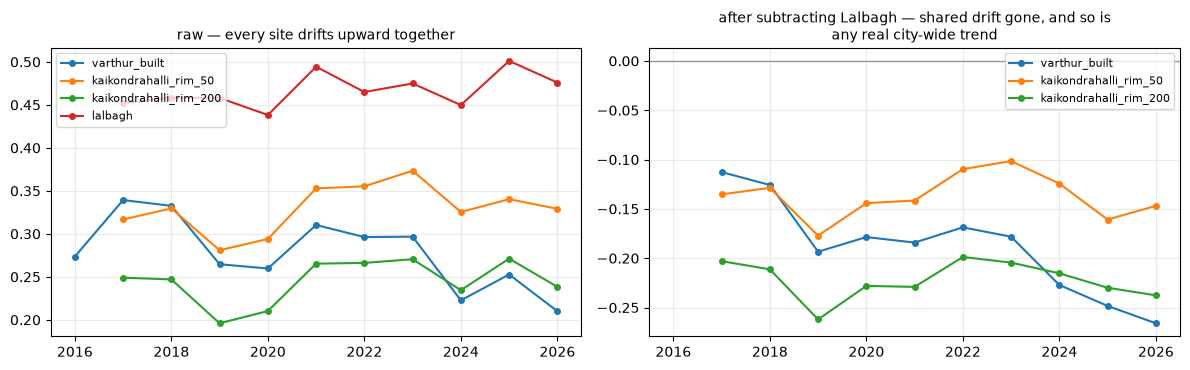

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
show = ["varthur_built", "kaikondrahalli_rim_50", "kaikondrahalli_rim_200", "lalbagh"]
for n in show:
    axes[0].plot(green.index, green[n], "o-", label=n, markersize=4)
axes[0].set_title("raw — every site drifts upward together", fontsize=10)
for n in show:
    if n == "lalbagh":
        continue
    axes[1].plot(green.index, green[n] - ctrl, "o-", label=n, markersize=4)
axes[1].axhline(0, color="#999", linewidth=1)
axes[1].set_title("after subtracting Lalbagh — shared drift gone, and so is\nany real city-wide trend", fontsize=10)
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

---
## Checking it against the pictures

Numbers this simple can be confidently wrong, so `render_sites.py` pulls the actual composite
behind each one. Greenness frames for Varthur, 2019 against 2026 — yellow is the measured area,
red is the lake, **excluded**.

Teal is high greenness, brown is low.

2019   greenness 0.265


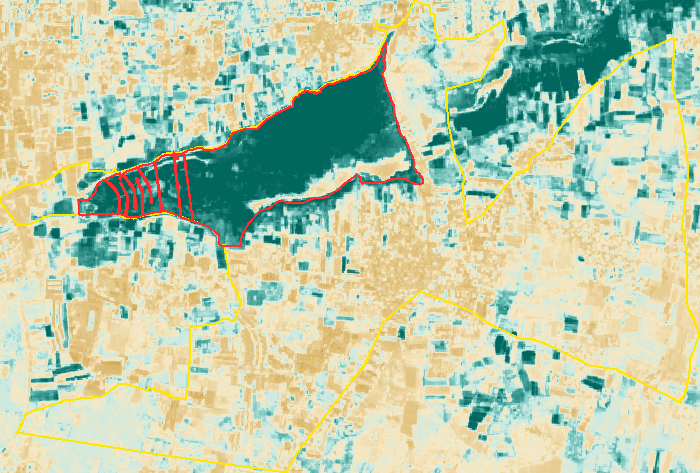

2026   greenness 0.210


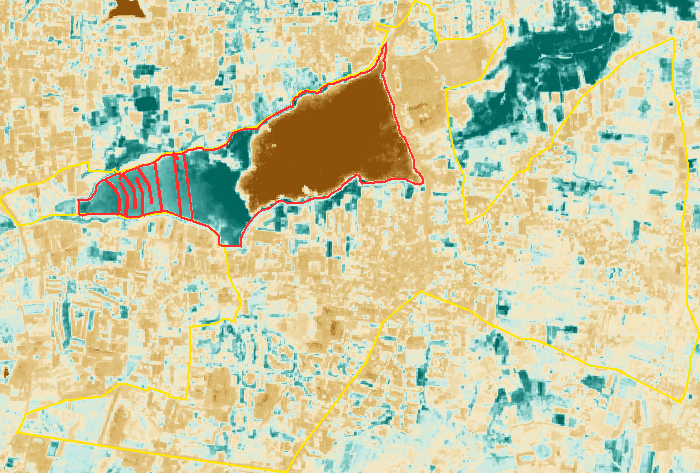

In [15]:
for y in (2019, 2026):
    print(f"{y}   greenness {green.loc[y, 'varthur_built']:.3f}")
    display(Image(filename=f"results/imagery/varthur_built_{y}_ndvi.png", width=620))

The lake reads **teal (high greenness)** in 2019 and **brown (near zero)** in 2026 — it sat at 0.82
greenness in 2017, higher than Lalbagh ever reaches.

Whatever is floating on it photosynthesises, so the arithmetic in step 4 cannot tell it from
forest. Most likely a water hyacinth mat, which is what Varthur is known for, but **nobody has
verified the species** — no high-resolution image, no source. Treat it as "dense vegetation
floating on water", on the same gotcha 7 discipline that applies to recalled coordinates and the
unverified restoration date below.

This is the failure mode gotcha 3 warns about, in its most extreme form — and it is a live hazard,
because the lake outline is a *fixed* polygon while the real water edge moves. If weed mat leaked
past that outline, its collapse would look exactly like canopy loss.

In [16]:
built = regions["varthur_built"]
def contamination(y):
    c = dry_season(y, built).median()
    gr = c.normalizedDifference(["B8", "B4"])
    wt = c.normalizedDifference(["B3", "B11"])
    img = wt.gt(0).rename("pct_water").addBands(wt.gt(0).And(gr.gt(0.3)).rename("pct_weed_mat"))
    return ee.Feature(None, img.reduceRegion(ee.Reducer.mean(), built, SCALE_M)).set("year", y)

leak = pd.DataFrame([f["properties"] for f in
                     ee.FeatureCollection([contamination(y) for y in FIT_YEARS]).getInfo()["features"]])
leak = leak.set_index("year") * 100
leak["pct_water"] = leak["pct_water"].round(2)
leak["pct_weed_mat"] = leak["pct_weed_mat"].round(2)
print("share of the measured Varthur area reading as water / weed mat, %\n")
leak[["pct_water", "pct_weed_mat"]]

share of the measured Varthur area reading as water / weed mat, %



,pct_water,pct_weed_mat
year,,
2019,0.12,0.01
2020,0.14,0.00
2021,0.23,0.00
2022,0.07,0.00
2023,0.15,0.00
2024,0.07,0.00
2025,0.26,0.00
2026,0.26,0.00


Water never exceeds 0.3% of the measured area and weed mat is 0.00% throughout. **The exclusion
holds and the loss is not a hyacinth artefact** — which is the first time that number has been
tested against anything but its own arithmetic.

---
## Where this leaves milestone 1

| direction | site | result |
|---|---|---|
| flat | Lalbagh | ✓ confirmed, and it is the control |
| loss | Varthur built-up area | ✓ confirmed, `t = 3.18`, survives the contamination check |
| gain | Kaikondrahalli rim | ✗ not established at any radius (50/100/200 m) |
| loss | Varthur lake's own 150 m rim | ✓ strongest in the project, but a sub-region of the row above |

The gain direction failed at all three ring widths with clean wetness readings, so it is not
dilution and not water contamination — the most likely reading is that the restoration predates the
window. That is unverified: nobody has checked the actual restoration date against a source.

**Open, and not for this notebook to settle:**

1. Year range — 2019–2026 as the headline, or keep the thin early years?
2. The gain direction — accept 2-of-3 and close it later from milestone 2's own top-gaining hexes,
   or name a restoration known to fall inside the window?
3. `varthur_lake_ring_150` in the fits table above is the strongest signal anywhere in this
   project, and the only one that holds up *without* the control. But it is carved out of
   `varthur_built`, so it is a *piece of* that number rather than independent corroboration of it —
   do not quote the two as if they agree with each other. It also has one reversal (2022), so
   "monotonic decline" would overstate it.
4. No cloud masking anywhere in this pipeline. Harmless at 12+ photos, not harmless at 2–4. Adding
   one would change every number in the thin years.